# Bài tập về nhà — Buổi 2: Xác suất thống kê cho AI

**Môn học:** Python & Machine Learning — Module 1: Toán học trong AI

**Dataset sử dụng:** Iris (từ thư viện seaborn)

Notebook này gồm 4 phần theo đúng yêu cầu đề bài:
1. Thống kê mô tả & đặc trưng
2. Phân phối xác suất
3. Phân tích đa biến & tương quan
4. Xác suất & Định lý Bayes

## Import thư viện và tải dữ liệu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# cài đặt style cho đồ thị cho dễ nhìn
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = sns.load_dataset("iris")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
print("Số dòng, số cột:", df.shape)
print()
print("Kiểu dữ liệu của từng cột:")
print(df.dtypes)

Số dòng, số cột: (150, 5)

Kiểu dữ liệu của từng cột:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


Dataset Iris có 150 dòng, 5 cột. 4 cột đầu (`sepal_length`, `sepal_width`, `petal_length`,
`petal_width`) là biến số (float), cột `species` là biến phân loại (3 loài: setosa,
versicolor, virginica).

---
## Phần 1 — Thống kê mô tả & đặc trưng

### 1.1. Các chỉ số mô tả cho mỗi biến số

In [3]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Các biến số:", num_cols)

desc = pd.DataFrame({
    "mean": df[num_cols].mean(),
    "median": df[num_cols].median(),
    "mode": df[num_cols].mode().iloc[0],
    "var": df[num_cols].var(),
    "std": df[num_cols].std(),
    "min": df[num_cols].min(),
    "max": df[num_cols].max(),
    "Q1": df[num_cols].quantile(0.25),
    "Q3": df[num_cols].quantile(0.75),
})
desc["IQR"] = desc["Q3"] - desc["Q1"]
desc.round(3)

Các biến số: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']


,mean,median,mode,var,std,min,max,Q1,Q3,IQR
sepal_length,5.843,5.80,5.0,0.686,0.828,4.3,7.9,5.1,6.4,1.3
sepal_width,3.057,3.00,3.0,0.190,0.436,2.0,4.4,2.8,3.3,0.5
petal_length,3.758,4.35,1.4,3.116,1.765,1.0,6.9,1.6,5.1,3.5
petal_width,1.199,1.30,0.2,0.581,0.762,0.1,2.5,0.3,1.8,1.5


**Nhận xét:** `petal_length` và `petal_width` có độ lệch chuẩn (std) và khoảng biến thiên
(IQR) lớn hơn hẳn so với `sepal_width` — nghĩa là 2 biến này phân tán rộng hơn, có khả năng
phân biệt tốt giữa các loài hoa. Ngược lại `sepal_width` khá tập trung quanh giá trị trung bình.

### 1.2. Thống kê theo từng nhóm (species)

In [4]:
group_stats = df.groupby("species")[num_cols].agg(["mean", "std"])
group_stats.round(3)

sepal_length        sepal_width        petal_length         \
                   mean    std        mean    std         mean    std   
species                                                                 
setosa            5.006  0.352       3.428  0.379        1.462  0.174   
versicolor        5.936  0.516       2.770  0.314        4.260  0.470   
virginica         6.588  0.636       2.974  0.322        5.552  0.552   

           petal_width         
                  mean    std  
species                        
setosa           0.246  0.105  
versicolor       1.326  0.198  
virginica        2.026  0.275

**Nhận xét:** Nhìn vào `petal_length` và `petal_width`, 3 loài có giá trị trung bình tách biệt
rõ rệt (setosa nhỏ nhất, virginica lớn nhất, std cũng nhỏ nên các nhóm ít chồng lấp lên nhau).
Đây là 2 biến phân biệt loài rõ nhất. Ngược lại `sepal_width` có mean giữa 3 loài khá gần nhau
nên không phân biệt tốt bằng.

---
## Phần 2 — Phân phối xác suất

### 2.1. Histogram + KDE cho từng biến số

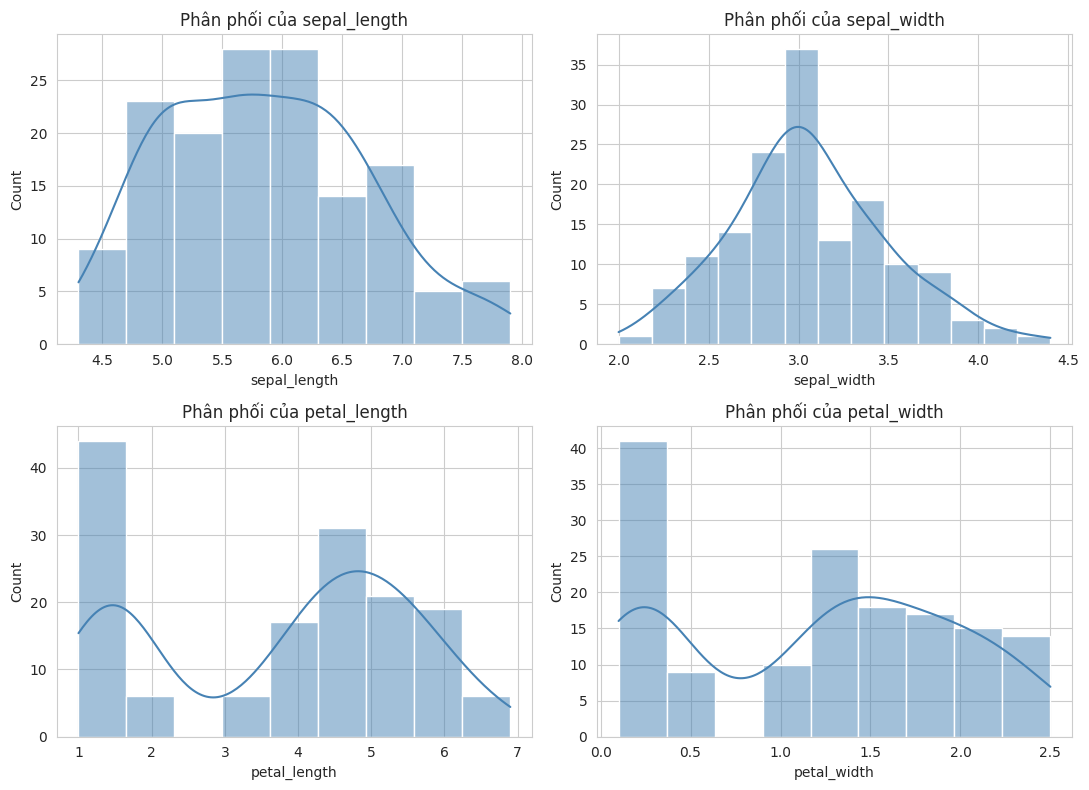

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Phân phối của {col}")

plt.tight_layout()
plt.show()

In [6]:
for col in num_cols:
    print(f"{col}: skewness = {df[col].skew():.3f}, kurtosis = {df[col].kurt():.3f}")

sepal_length: skewness = 0.315, kurtosis = -0.552
sepal_width: skewness = 0.319, kurtosis = 0.228
petal_length: skewness = -0.275, kurtosis = -1.402
petal_width: skewness = -0.103, kurtosis = -1.341


**Nhận xét hình dạng phân phối:**
- `sepal_length`, `sepal_width`: khá gần phân phối chuẩn, lệch nhẹ về phải (skew dương nhỏ).
- `petal_length`, `petal_width`: có 2 đỉnh rõ rệt (bimodal) — do dữ liệu là trộn của 3 loài
  hoa khác nhau, mỗi loài có một "cụm" giá trị riêng nên khi gộp lại nhìn như 2-3 đỉnh, không
  phải phân phối chuẩn đơn giản.

### 2.2. Boxplot từng biến theo nhóm species

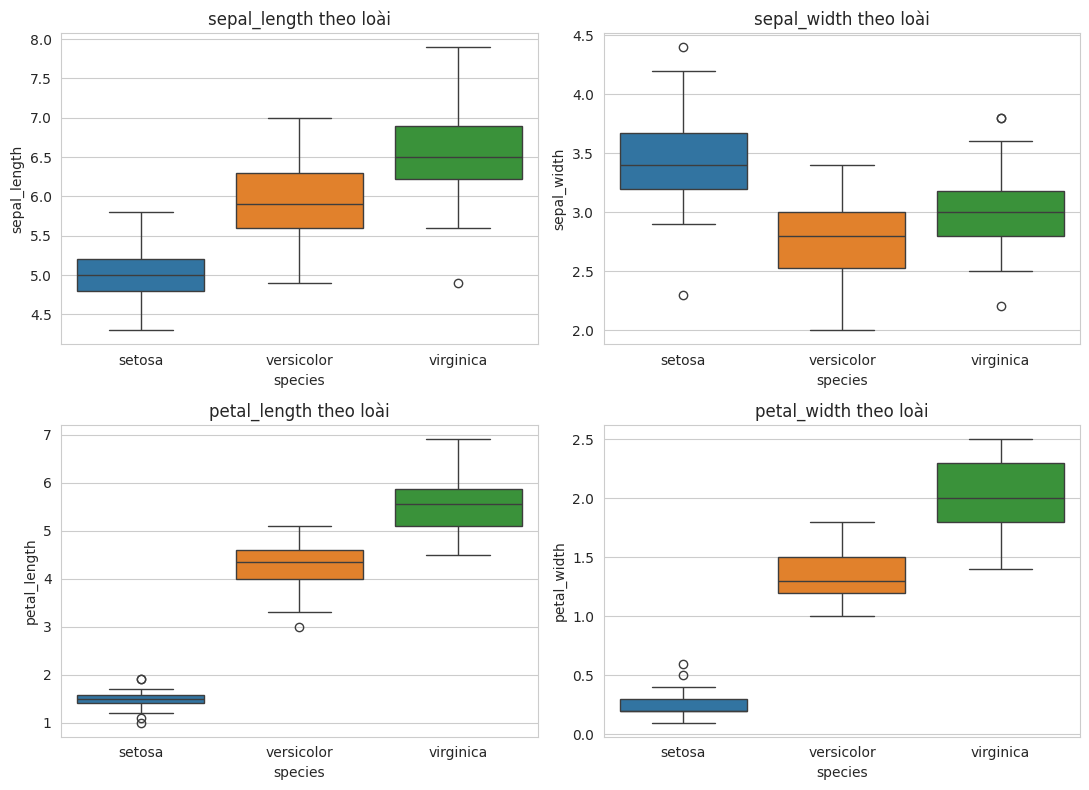

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x="species", y=col, hue="species", ax=axes[i], legend=False)
    axes[i].set_title(f"{col} theo loài")

plt.tight_layout()
plt.show()

**Nhận xét:** `petal_length` và `petal_width` tách 3 loài ra rất rõ ràng, hầu như không
chồng lấp (đặc biệt setosa tách biệt hoàn toàn với 2 loài còn lại). `sepal_width` thì các
hộp boxplot chồng lấp nhiều, khó phân biệt loài chỉ dựa vào biến này.

### 2.3. Mô phỏng phân phối Normal và so sánh với dữ liệu thực tế

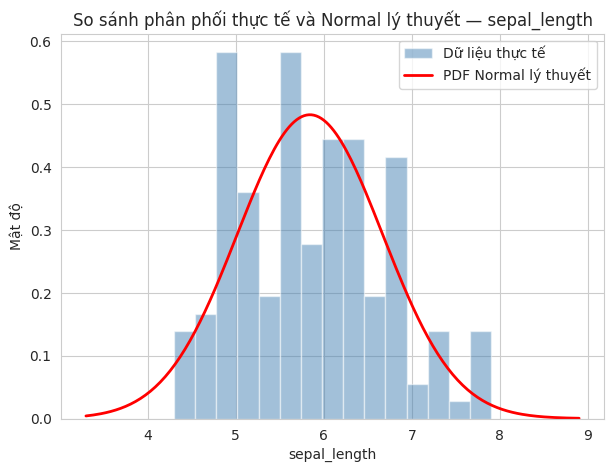

mean = 5.843, std = 0.825


In [8]:
col = "sepal_length"
data = df[col].values
mu, sigma = data.mean(), data.std()

# sinh mẫu giả lập từ phân phối Normal cùng mean, std với dữ liệu thật
sim = np.random.normal(mu, sigma, size=10000)

plt.figure(figsize=(7, 5))
plt.hist(data, bins=15, density=True, alpha=0.5, label="Dữ liệu thực tế", color="steelblue")

x = np.linspace(data.min() - 1, data.max() + 1, 200)
plt.plot(x, stats.norm.pdf(x, mu, sigma), color="red", lw=2, label="PDF Normal lý thuyết")

plt.title(f"So sánh phân phối thực tế và Normal lý thuyết — {col}")
plt.xlabel(col)
plt.ylabel("Mật độ")
plt.legend()
plt.show()

print(f"mean = {mu:.3f}, std = {sigma:.3f}")

**Nhận xét:** Đường PDF Normal lý thuyết khớp khá tốt với hình dạng tổng thể của histogram
thực tế (đều có dạng hình chuông quanh giá trị trung bình ~5.8). Tuy nhiên dữ liệu thực tế
không hoàn toàn trơn như lý thuyết — có vài "răng cưa" do mẫu nhỏ (150 quan sát) và do dữ liệu
là tổng hợp từ 3 loài hoa khác nhau, không phải sinh ra từ một phân phối Normal đơn nhất.

---
## Phần 3 — Phân tích đa biến & tương quan

### 3.1. Ma trận hiệp phương sai và tương quan

In [9]:
cov_matrix = df[num_cols].cov()
corr_matrix = df[num_cols].corr()

print("Ma trận hiệp phương sai (covariance):")
display(cov_matrix.round(3))

print("\nMa trận tương quan (correlation):")
display(corr_matrix.round(3))

Ma trận hiệp phương sai (covariance):


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.686,-0.042,1.274,0.516
sepal_width,-0.042,0.190,-0.330,-0.122
petal_length,1.274,-0.330,3.116,1.296
petal_width,0.516,-0.122,1.296,0.581



Ma trận tương quan (correlation):


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000,-0.118,0.872,0.818
sepal_width,-0.118,1.000,-0.428,-0.366
petal_length,0.872,-0.428,1.000,0.963
petal_width,0.818,-0.366,0.963,1.000


### 3.2. Heatmap tương quan

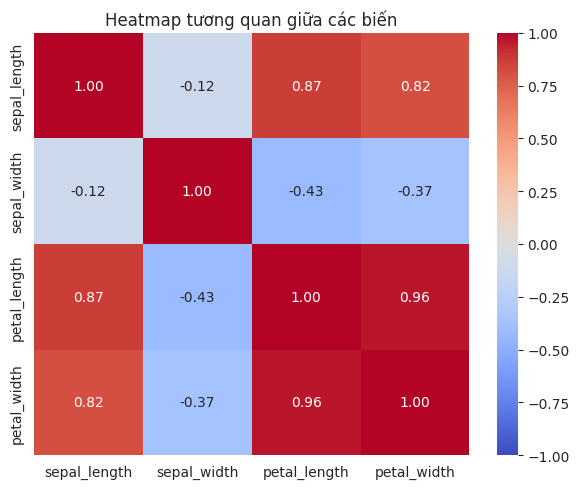

In [10]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Heatmap tương quan giữa các biến")
plt.tight_layout()
plt.show()

In [11]:
# tìm cặp biến tương quan mạnh nhất (bỏ qua đường chéo)
corr_abs = corr_matrix.abs().to_numpy().copy()
np.fill_diagonal(corr_abs, 0)
corr_abs = pd.DataFrame(corr_abs, index=corr_matrix.index, columns=corr_matrix.columns)

max_pair = corr_abs.stack().idxmax()
max_val = corr_matrix.loc[max_pair]
print(f"Cặp tương quan mạnh nhất: {max_pair} -> r = {max_val:.3f}")

Cặp tương quan mạnh nhất: ('petal_length', 'petal_width') -> r = 0.963


**Nhận xét:** Cặp `petal_length` và `petal_width` có tương quan mạnh nhất (r ≈ 0.96) —
gần như tuyến tính hoàn hảo. `sepal_length` cũng tương quan khá mạnh với cả hai biến petal
(r ≈ 0.87 và 0.82). Riêng `sepal_width` tương quan âm và yếu hơn với các biến còn lại.

Việc `petal_length`, `petal_width` và `sepal_length` cùng tương quan rất mạnh với nhau là dấu
hiệu của **đa cộng tuyến (multicollinearity)** — nếu dùng cả 3 biến này làm input cho mô hình
hồi quy tuyến tính thì có thể gây bất ổn cho hệ số ước lượng.

### 3.3. Pairplot theo loài

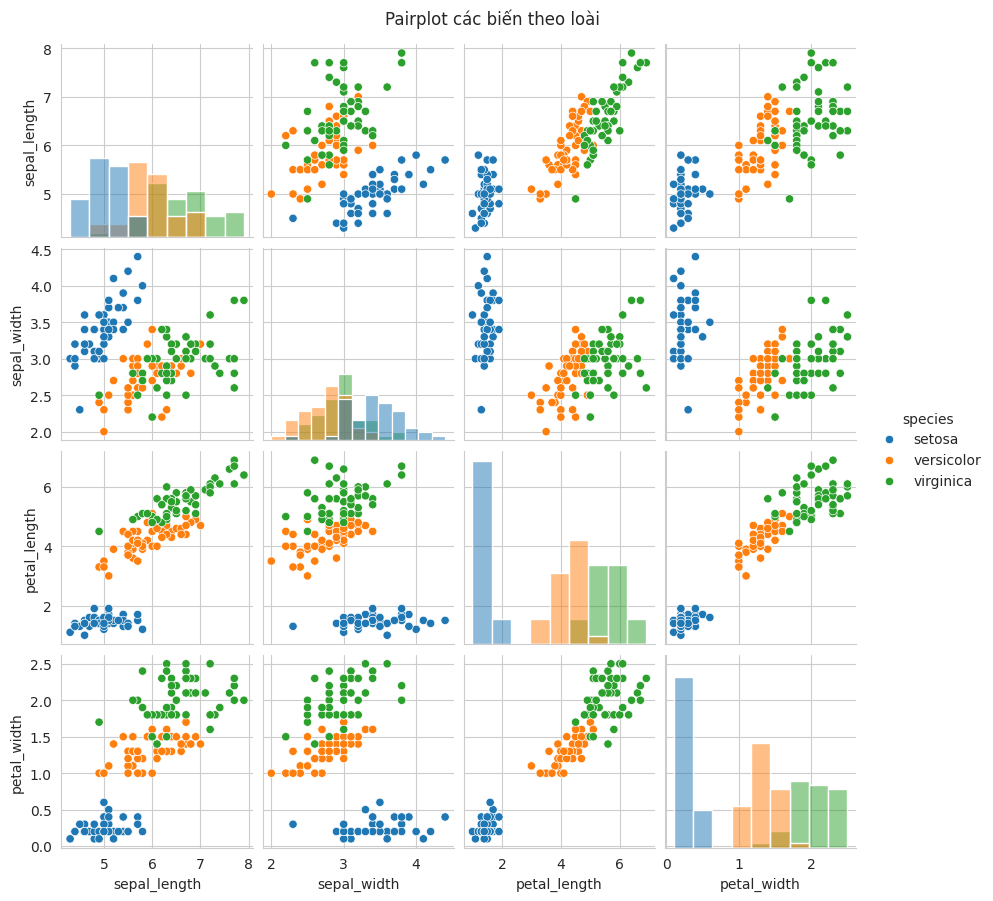

In [12]:
g = sns.pairplot(df, hue="species", diag_kind="hist", height=2.2)
g.figure.suptitle("Pairplot các biến theo loài", y=1.02)
plt.show()

**Nhận xét:** Pairplot cho thấy rõ loài setosa (xanh) tách biệt hoàn toàn khỏi 2 loài còn
lại ở hầu hết các cặp biến, đặc biệt là các cặp liên quan đến `petal_length`/`petal_width`.
Versicolor và virginica có chồng lấp nhau nhiều hơn nhưng vẫn phân biệt được phần nào, đặc biệt
khi nhìn vào petal_length vs petal_width — gần như tạo thành 1 đường tuyến tính rõ ràng, khớp
với hệ số tương quan rất cao tính ở trên.

---
## Phần 4 — Xác suất & Định lý Bayes

**Bài toán:** Một bệnh có tỉ lệ mắc trong dân số $P(B) = 0.01$. Xét nghiệm có độ nhạy
$P(+|B) = 0.99$ và tỉ lệ dương tính giả $P(+|\lnot B) = 0.05$.

### 4.1. Tính P(B|+) bằng định lý Bayes

In [13]:
P_B = 0.01
P_pos_givenB = 0.99
P_pos_givenNB = 0.05

# P(+) = P(+|B)*P(B) + P(+|notB)*P(notB)
P_pos = P_pos_givenB * P_B + P_pos_givenNB * (1 - P_B)

# Bayes: P(B|+) = P(+|B)*P(B) / P(+)
P_B_given_pos = P_pos_givenB * P_B / P_pos

print(f"P(+) = {P_pos:.4f}")
print(f"P(B|+) = {round(P_B_given_pos, 4)}  (~{P_B_given_pos*100:.2f}%)")

P(+) = 0.0594
P(B|+) = 0.1667  (~16.67%)


**Nhận xét:** Dù xét nghiệm có độ nhạy rất cao (99%), nhưng khi cho kết quả dương tính,
xác suất thực sự mắc bệnh chỉ khoảng **16.67%**. Nghe có vẻ phản trực giác nhưng hoàn toàn hợp
lý — sẽ giải thích rõ ở phần sau.

### 4.2. Khảo sát P(B|+) khi P(B) thay đổi

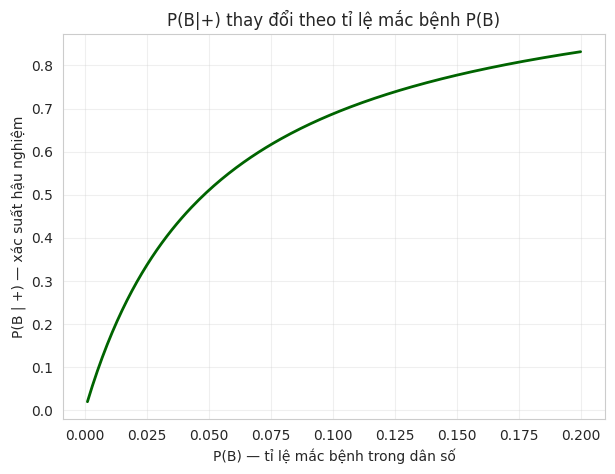

In [14]:
p_b_range = np.linspace(0.001, 0.2, 200)

p_b_given_pos_range = (P_pos_givenB * p_b_range) / (
    P_pos_givenB * p_b_range + P_pos_givenNB * (1 - p_b_range)
)

plt.figure(figsize=(7, 5))
plt.plot(p_b_range, p_b_given_pos_range, color="darkgreen", lw=2)
plt.xlabel("P(B) — tỉ lệ mắc bệnh trong dân số")
plt.ylabel("P(B | +) — xác suất hậu nghiệm")
plt.title("P(B|+) thay đổi theo tỉ lệ mắc bệnh P(B)")
plt.grid(alpha=0.3)
plt.show()

**Giải thích vì sao kết quả "phản trực giác" khi bệnh hiếm:**

Khi bệnh rất hiếm (P(B) nhỏ), số người **thực sự mắc bệnh** trong dân số rất ít. Trong khi đó,
nhóm người **không mắc bệnh** lại rất lớn, và dù tỉ lệ dương tính giả chỉ 5%, nhưng vì nhóm
"không mắc bệnh" quá đông, số ca dương tính giả tuyệt đối vẫn áp đảo so với số ca dương tính
thật (từ nhóm mắc bệnh ít). Kết quả là trong tổng số người có kết quả dương tính, phần lớn lại
là dương tính giả — nên P(B|+) thấp hơn nhiều so với độ nhạy 99% mà ta hay nhầm tưởng.

Nhìn vào đồ thị, P(B|+) tăng dần khi P(B) tăng — bệnh phổ biến hơn thì kết quả dương tính
đáng tin hơn.

### 4.3. (Bonus) Bộ lọc spam đơn giản theo Naive Bayes

In [15]:
spam_keywords = ["miễn phí", "trúng thưởng", "khuyến mãi", "click ngay", "giảm giá"]
ham_keywords = ["họp", "báo cáo", "dự án", "deadline", "tài liệu"]

P_spam = 0.4
P_ham = 0.6

# xác suất giả định: nếu email là spam thì có 70% khả năng chứa 1 từ khóa "spam" cho trước
# và chỉ 5% khả năng chứa 1 từ khóa "ham" (và ngược lại với email ham)
P_kw_given_spam = 0.7
P_kw_given_ham = 0.05

def keyword_features(text, keywords):
    text = text.lower()
    return [1 if kw in text else 0 for kw in keywords]

def predict_spam(email_text):
    spam_feats = keyword_features(email_text, spam_keywords)
    ham_feats = keyword_features(email_text, ham_keywords)

    p_x_given_spam = 1.0
    p_x_given_ham = 1.0

    for present in spam_feats:
        p_x_given_spam *= P_kw_given_spam if present else (1 - P_kw_given_spam)
        p_x_given_ham *= P_kw_given_ham if present else (1 - P_kw_given_ham)

    for present in ham_feats:
        p_x_given_spam *= P_kw_given_ham if present else (1 - P_kw_given_ham)
        p_x_given_ham *= P_kw_given_spam if present else (1 - P_kw_given_spam)

    numerator = p_x_given_spam * P_spam
    denominator = numerator + p_x_given_ham * P_ham
    return numerator / denominator

emails = [
    "khuyến mãi giảm giá click ngay",
    "họp dự án báo cáo deadline",
    "trúng thưởng miễn phí ngay hôm nay",
]

for email in emails:
    p = predict_spam(email)
    label = "SPAM" if p > 0.5 else "HAM"
    print(f"'{email}'")
    print(f"  -> P(spam|email) = {p:.4f}  =>  {label}\n")

'khuyến mãi giảm giá click ngay'
  -> P(spam|email) = 1.0000  =>  SPAM

'họp dự án báo cáo deadline'
  -> P(spam|email) = 0.0000  =>  HAM

'trúng thưởng miễn phí ngay hôm nay'
  -> P(spam|email) = 0.9992  =>  SPAM



**Nhận xét:** 2 email chứa nhiều từ khóa quảng cáo/khuyến mãi đều được phân loại đúng là
SPAM với xác suất gần 1, còn email công việc bình thường (họp, báo cáo, deadline) được phân
loại đúng là HAM với xác suất spam gần 0. Bộ lọc đơn giản này hoạt động theo nguyên lý Naive
Bayes: giả định các từ khóa xuất hiện độc lập với nhau, nhân các xác suất điều kiện lại rồi
áp dụng định lý Bayes để ra xác suất hậu nghiệm.

---
## Kết luận chung

- Các biến liên quan đến cánh hoa (petal) phân biệt 3 loài rõ ràng hơn nhiều so với các biến đài hoa (sepal).
- `petal_length` và `petal_width` có tương quan rất mạnh với nhau, cần lưu ý đa cộng tuyến nếu dùng làm input cho mô hình tuyến tính.
- Định lý Bayes cho thấy với bệnh hiếm, một xét nghiệm có độ nhạy cao vẫn có thể cho xác suất hậu nghiệm dương tính thật thấp hơn nhiều so với kỳ vọng ban đầu — đây là bài học quan trọng khi diễn giải kết quả xét nghiệm y tế.